# Phase 12 — Model Evaluation Rollup

**คู่เปรียบเทียบหลัก: Global LightGBM กับ Global XGBoost**

Phase นี้นำผลพยากรณ์มาประเมินและสรุปเพื่อใช้ต่อใน Phase 13 โดยใช้ข้อมูล features,
target และ 7 walk-forward folds เดิม ไม่ปรับ hyperparameters และยังคง LightGBM เป็นโมเดลหลัก

ตารางหลักเปรียบเทียบความแม่นยำและความสม่ำเสมอของ LightGBM/XGBoost บนแถวเดียวกันทั้งหมด
ส่วน baseline, Local LightGBM, Random Forest, ablation และ DL embeddings เป็นผลประกอบ
ผล ETS/cold-start นำจาก output ที่บันทึกใน notebook เดิมและแยก protocol ชัดเจน
ไม่มีการ fit/score บน **10 holdout origin weeks** และไม่มีการอ่าน batch มกราคม 2025


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'src/models/evaluation.py').is_file(), (
    'Could not locate repo root: expected an ancestor directory containing '
    'src/models/evaluation.py (run from the repo root or any notebooks/ subfolder)'
)
sys.path.insert(0, str(ROOT / 'src'))

from models.evaluation import (
    FOCUS, CORE, run_cv, export_reports, load_recorded_results,
    summarize_predictions, validate_ledger,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
recorded, recorded_sources = load_recorded_results(ROOT)
print('Verified saved ETS/cold-start outputs before training:', len(recorded), 'rows')

Verified saved ETS/cold-start outputs before training: 8 rows


## 1. รัน CV เดิมครั้งเดียวต่อ model/variant ต่อ fold

- Initial training ถึง 2023-09-30, validation ครั้งละ 8 สัปดาห์, กัน 10 สัปดาห์สุดท้ายไว้
- แบ่งตาม `week` (forecast origin) ด้วย splitter เดิม; label `target_next_week` เดิมไม่ถูกเปลี่ยน
- คู่หลักใช้ `ALL_FEATURE_COLS` เหมือนกัน แต่ใช้ objective/configuration เดิมของแต่ละ library
  (LightGBM: L2 regression, XGBoost: absolute-error regression)
- จับคู่ prediction กับ actual ด้วย `sku × channel × region × week`; index ที่เปลี่ยนหลัง DL merge ไม่มีผล
- Full LightGBM เทรน 1 ครั้งต่อ fold แล้วนำ predictions เดิมมาเป็น reference ของ ablation/DL
- NaN ของ Seasonal Naive และ Local model ถ้ามีจะถูกเก็บไว้เพื่อรายงาน coverage ไม่เติม fallback


In [2]:
ledger, registry, folds, holdout, feature_groups = run_cv(ROOT, progress=lambda _: None, checkpoint_dir=ROOT / 'reports/.phase12-cache')
print(f'Completed {len(folds)} folds, {len(registry)} distinct model/variants')
print('Reserved holdout origin weeks:', pd.Timestamp(holdout.min()).date(), 'to', pd.Timestamp(holdout.max()).date())
print('Prediction ledger rows:', len(ledger))


Completed 7 folds, 14 distinct model/variants
Reserved holdout origin weeks: 2024-10-21 to 2024-12-23
Prediction ledger rows: 207900


## 2. สร้างตารางและไฟล์ที่ตรวจย้อนกลับได้

ไฟล์ทั้งหมดอยู่ใน `reports/phase12/`: ตารางรวม, คะแนนราย fold, CV predictions,
manifest และกราฟคู่หลัก ผล recorded อยู่เฉพาะในตารางรวม ไม่มีการสร้าง predictions ย้อนหลังขึ้นมา

**MAE/RMSE มีหน่วยเป็นจำนวนขาย; WAPE/SMAPE เป็น ratio** (0.224 = 22.4%)
คะแนนสรุปเป็นค่าเฉลี่ยราย fold แบบน้ำหนักเท่ากัน ไม่ใช่คะแนนจากการรวมทุก prediction
`WAPE_std` เป็น sample standard deviation (`ddof=1`) ไม่ใช่ confidence interval
หาก actual รวมเป็นศูนย์ใน fold คะแนน WAPE จะเป็น undefined และส่งต่อเป็น `N/A` ในผลสรุป


In [3]:
summary, fold_scores, manifest = export_reports(ROOT, ledger, registry, folds, holdout, feature_groups)
OUT = ROOT / 'reports/phase12'
print('Saved:', ', '.join(sorted(p.name for p in OUT.iterdir())))
print('CV predictions only; January 2025 batches read:', manifest['january_2025_batches_read'])


Saved: fold_scores.csv, model_comparison.csv, model_comparison.png, predictions.csv, run_manifest.json
CV predictions only; January 2025 batches read: False


## 3. ผลหลัก: LightGBM vs XGBoost

คู่หลักใช้ **full CV coverage ที่ตรงกัน** โดยไม่ลดชุดประเมินตามแถวที่ Seasonal Naive ขาดประวัติ
WAPE ต่ำกว่าหมายถึงความคลาดเคลื่อนโดยรวมต่ำกว่า; std ต่ำกว่าหมายถึงคะแนน 7 folds กระจายน้อยกว่า
ข้อสรุปนี้เป็นการเปรียบเทียบเชิงพรรณนา ไม่ใช่การยืนยันความแตกต่างหรือความเท่ากันทางสถิติ


,model,MAE,RMSE,WAPE,SMAPE,WAPE_std,n_folds,n_scored,coverage
model_id,,,,,,,,,
global_lgb,Global LightGBM,25.166355,32.249746,0.223513,0.227965,0.006184,7.0,14850.0,1.0
global_xgb,Global XGBoost,25.226536,32.389407,0.224009,0.228538,0.005838,7.0,14850.0,1.0


model_id,global_lgb,global_xgb,XGBoost_minus_LightGBM
fold_id,,,
1,0.232382,0.231723,-0.000659
2,0.231724,0.231926,0.000202
3,0.220026,0.219074,-0.000952
4,0.223670,0.225939,0.002270
5,0.220065,0.219456,-0.000610
6,0.216604,0.219285,0.002680
7,0.220116,0.220662,0.000546


Mean WAPE: LightGBM 0.223513 (22.351%), XGBoost 0.224009 (22.401%)
XGBoost - LightGBM: +0.000497 ratio = +0.0497 percentage points
Lowest observed mean: Global LightGBM
Lowest observed fold std: Global XGBoost
Primary model carried forward: Global LightGBM. These descriptive differences alone do not establish significance or equivalence.


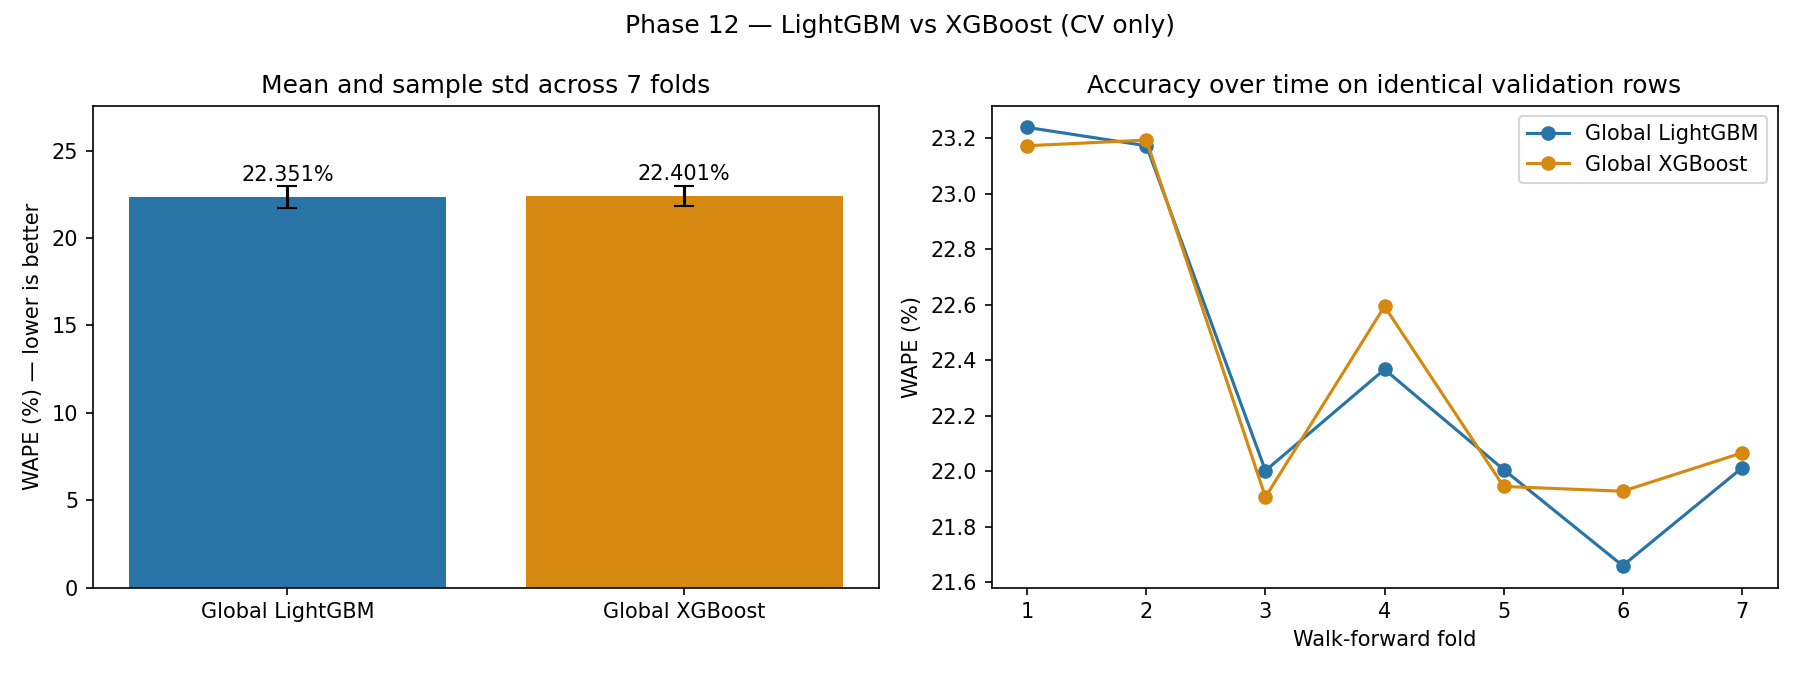

In [4]:
focus = summary[(summary.source == 'rerun') & (summary.comparison_group == 'core_cv')
                & summary.model_id.isin(FOCUS)].set_index('model_id').loc[FOCUS]
assert focus.cohort_hash.nunique() == 1, 'Focus models must score identical keys'
display(focus[['model', 'MAE', 'RMSE', 'WAPE', 'SMAPE', 'WAPE_std', 'n_folds', 'n_scored', 'coverage']].round(6))

focus_folds = fold_scores[(fold_scores.comparison_group == 'core_cv') & fold_scores.model_id.isin(FOCUS)]
by_fold = focus_folds.pivot(index='fold_id', columns='model_id', values='WAPE')[FOCUS]
by_fold['XGBoost_minus_LightGBM'] = by_fold.global_xgb - by_fold.global_lgb
display(by_fold.round(6))

lgb, xgb = focus.loc['global_lgb'], focus.loc['global_xgb']
lower_mean = focus.WAPE.idxmin()
lower_std = focus.WAPE_std.idxmin()
print(f"Mean WAPE: LightGBM {lgb.WAPE:.6f} ({lgb.WAPE*100:.3f}%), XGBoost {xgb.WAPE:.6f} ({xgb.WAPE*100:.3f}%)")
print(f"XGBoost - LightGBM: {xgb.WAPE-lgb.WAPE:+.6f} ratio = {(xgb.WAPE-lgb.WAPE)*100:+.4f} percentage points")
print('Lowest observed mean:', focus.loc[lower_mean, 'model'])
print('Lowest observed fold std:', focus.loc[lower_std, 'model'])
print('Primary model carried forward: Global LightGBM. These descriptive differences alone do not establish significance or equivalence.')
display(Image(filename=str(OUT / 'model_comparison.png')))


## 4. ผลประกอบ: baseline/core และ coverage

คะแนน `core_cv` ใช้แถวที่แต่ละโมเดลมี prediction โดยแสดงจำนวนแถวและ coverage เสมอ
`rank_group` ระบุชุดแถวเดียวกันที่จัดอันดับร่วมกันได้ ห้ามเทียบ rank ข้าม rank_group
หากมี coverage ต่างกัน จะมี `core_common` ซึ่งใช้ intersection ของ keys ที่พยากรณ์ได้ทุกโมเดลในแต่ละ fold
ตารางนี้ใช้เปรียบเทียบ baseline/core ทั้ง 7 ตัวอย่างยุติธรรม และแยกจาก full-coverage คู่หลัก


In [5]:
cols = ['model', 'MAE', 'RMSE', 'WAPE', 'SMAPE', 'WAPE_std', 'n_scored', 'n_eligible', 'coverage', 'rank', 'rank_group']
display(summary[summary.comparison_group.eq('core_cv')][cols].round(6))
common = summary[summary.comparison_group.eq('core_common')]
if len(common):
    display(common[cols].round(6))
else:
    print('All 7 core models already share coverage; no duplicate common-coverage table is needed.')


,model,MAE,RMSE,WAPE,SMAPE,WAPE_std,n_scored,n_eligible,coverage,rank,rank_group
0,Naive,34.224632,43.846762,0.303736,0.307448,0.005629,14850.0,14850.0,1.000000,6.0,core_cv:279055acaa84b30bc190e87852ce13c28a467b...
1,Seasonal Naive,39.934828,51.327590,0.356191,0.337963,0.013223,11899.0,14850.0,0.801279,NaN,NaN
2,Moving Average (4w),27.348262,35.133872,0.242785,0.245849,0.005854,14850.0,14850.0,1.000000,4.0,core_cv:279055acaa84b30bc190e87852ce13c28a467b...
3,Local per-SKU LightGBM,28.798603,36.818800,0.256518,0.256813,0.021239,14850.0,14850.0,1.000000,5.0,core_cv:279055acaa84b30bc190e87852ce13c28a467b...
4,Global LightGBM,25.166355,32.249746,0.223513,0.227965,0.006184,14850.0,14850.0,1.000000,1.0,core_cv:279055acaa84b30bc190e87852ce13c28a467b...
5,Global XGBoost,25.226536,32.389407,0.224009,0.228538,0.005838,14850.0,14850.0,1.000000,2.0,core_cv:279055acaa84b30bc190e87852ce13c28a467b...
6,Global Random Forest,25.235499,32.307293,0.224077,0.228692,0.003945,14850.0,14850.0,1.000000,3.0,core_cv:279055acaa84b30bc190e87852ce13c28a467b...


,model,MAE,RMSE,WAPE,SMAPE,WAPE_std,n_scored,n_eligible,coverage,rank,rank_group
16,Naive,33.929589,43.514250,0.302404,0.306285,0.006714,11899.0,14850.0,0.801279,6.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...
17,Seasonal Naive,39.934828,51.327590,0.356191,0.337963,0.013223,11899.0,14850.0,0.801279,7.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...
18,Moving Average (4w),26.934415,34.599812,0.240085,0.243617,0.007484,11899.0,14850.0,0.801279,4.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...
19,Local per-SKU LightGBM,28.139201,35.913736,0.251778,0.253292,0.014043,11899.0,14850.0,0.801279,5.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...
20,Global LightGBM,24.890423,31.831605,0.222189,0.226858,0.005435,11899.0,14850.0,0.801279,1.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...
21,Global XGBoost,24.952427,32.005965,0.222657,0.227378,0.005058,11899.0,14850.0,0.801279,2.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...
22,Global Random Forest,25.023046,31.976314,0.223336,0.228113,0.005144,11899.0,14850.0,0.801279,3.0,core_common:1270cf6f2ea46f4286a8376de16b498ffb...


## 5. ผลประกอบ: ablation และ DL embeddings

`delta_WAPE = variant WAPE - full LightGBM WAPE` จากรอบรันเดียวกัน
ค่าบวกหมายถึง variant คลาดเคลื่อนมากขึ้นเมื่อเทียบ reference; ค่าลบหมายถึงลดลง
ฟีเจอร์ weather/inflation เดิมเป็น synthetic proxies จึงไม่ใช้ผลนี้สรุปว่า external data จริงไม่มีประโยชน์
DL embeddings fit เฉพาะ training fold และยังเป็นการทดลองเสริม
ไม่เพิ่ม hypothesis tests และไม่นำ p-values จาก notebook เก่ามาใช้กับคะแนนใหม่


In [6]:
variant_cols = ['model', 'comparison_group', 'WAPE', 'WAPE_std', 'delta_WAPE', 'coverage']
display(summary[summary.comparison_group.isin(['ablation_cv', 'dl_cv'])][variant_cols].round(6))


,model,comparison_group,WAPE,WAPE_std,delta_WAPE,coverage
7,LightGBM without lag_rolling,ablation_cv,0.226487,0.007062,0.002974,1.0
8,LightGBM without price,ablation_cv,0.223755,0.006342,0.000242,1.0
9,LightGBM without promotion,ablation_cv,0.223919,0.005170,0.000406,1.0
10,LightGBM without external_enrichment,ablation_cv,0.223501,0.005983,-0.000011,1.0
11,LightGBM without calendar_lifecycle,ablation_cv,0.229783,0.011107,0.006270,1.0
12,LightGBM without operational,ablation_cv,0.223957,0.005261,0.000444,1.0
13,LightGBM + DL embeddings,dl_cv,0.223726,0.006101,0.000214,1.0
14,Global LightGBM,ablation_cv,0.223513,0.006184,0.000000,1.0
15,Global LightGBM,dl_cv,0.223513,0.006184,0.000000,1.0


## 6. ผลอ้างอิงเดิม: ETS และ cold-start

- **ETS:** top-5 series ถูกเลือกจากยอดรวมทั้งตาราง; ETS ใช้ forecast หลายสัปดาห์จาก origin เดียว
  และ alignment ของ target/origin ต่างจาก ML จึงใช้เป็นผลอ้างอิงเดิม ไม่จัดอันดับกับผล CV ใหม่
  notebook เดิมไม่ได้บันทึกจำนวน fits/แถวที่สำเร็จครบถ้วน จึงไม่เดา coverage, counts หรือ std
- **Cold-start:** กัน 5 SKUs ออกทั้ง SKU แต่ไม่ได้เป็น temporal CV เดียวกับคู่หลัก
  วิธี fit เดิมอาจใช้ช่วงเวลาหลังวันที่ประเมิน จึงไม่ตีความเป็นการทดสอบพยากรณ์ ณ วันเปิดตัวจริง
  อายุเริ่มจากแถวแรกใน modeling table ไม่ใช่ zero-history launch; Analog อาจประเมินแถวน้อยกว่า ML
- ผล recorded คง precision 3 ตำแหน่งตาม output ที่มี ค่าอื่นที่ไม่มีแสดง `N/A`
  source notebook, cell/output index, hash และตัวเลขข้อความต้นฉบับอยู่ใน manifest


In [7]:
historical = summary[summary.source.eq('recorded')]
display(historical[['model', 'comparison_group', 'MAE', 'RMSE', 'WAPE', 'SMAPE',
                    'WAPE_std', 'n_folds', 'n_scored', 'coverage', 'source_notebook']].fillna('N/A'))


,model,comparison_group,MAE,RMSE,WAPE,SMAPE,WAPE_std,n_folds,n_scored,coverage,source_notebook
23,Global LightGBM (same top-5 series),recorded_ets_top5,28.363,34.93,0.214,0.216,N/A,N/A,N/A,N/A,notebooks/01_forecasting/07_core_forecasting.i...
24,ETS (Holt-Winters),recorded_ets_top5,39.11,47.418,0.301,0.292,N/A,N/A,N/A,N/A,notebooks/01_forecasting/07_core_forecasting.i...
25,Analog,recorded_cold_0_7,N/A,N/A,0.326,N/A,N/A,N/A,N/A,N/A,notebooks/04_cold_start/10_cold_start.ipynb
26,Meta-learner,recorded_cold_0_7,N/A,N/A,0.255,N/A,N/A,N/A,N/A,N/A,notebooks/04_cold_start/10_cold_start.ipynb
27,Full LightGBM,recorded_cold_0_7,N/A,N/A,0.241,N/A,N/A,N/A,N/A,N/A,notebooks/04_cold_start/10_cold_start.ipynb
28,Analog,recorded_cold_8_plus,N/A,N/A,0.339,N/A,N/A,N/A,N/A,N/A,notebooks/04_cold_start/10_cold_start.ipynb
29,Meta-learner,recorded_cold_8_plus,N/A,N/A,0.241,N/A,N/A,N/A,N/A,N/A,notebooks/04_cold_start/10_cold_start.ipynb
30,Full LightGBM,recorded_cold_8_plus,N/A,N/A,0.240,N/A,N/A,N/A,N/A,N/A,notebooks/04_cold_start/10_cold_start.ipynb


## 7. บริบทจาก Phase 8–9

[Promotion effect — Phase 8](../02_promotions/08_promotion_effect.ipynb) และ [robustness — Phase 8b](../02_promotions/08b_promotion_robustness.ipynb):
TWFE ประเมิน sales uplift ประมาณ +28.4% แต่ยังไม่พิสูจน์ causal identification หรือ profitability
จึงไม่มีการนำ uplift มาเทียบอันดับกับ WAPE

[Seasonality/trend — Phase 9](../03_seasonality/09_seasonality_trend.ipynb): pattern แตกต่างตามหมวดสินค้า
กรณี Milk ต้องพิจารณา per-SKU robustness เพราะจำนวน SKU ที่โตขึ้นทำให้ sum-based trend ดูสูงเกินจริง
ผล STL เป็นบริบทการวางแผน ไม่ใช่คะแนนความแม่นยำของ forecast model

## 8. Environment และผลต่างจากรอบเดิม

ล็อกเดิมบันทึก Python 3.9.6 บน macOS; manifest ระบุ environment ที่รัน Phase 12 จริง
คะแนนเก่าใน README และ Phase ก่อนหน้าไม่ถูกแก้ทับ
ตารางด้านล่างเปรียบเทียบค่าเฉลี่ยคู่หลักกับ output สรุปใน Phase 7 โดยคง precision ของต้นฉบับ
ผลต่างข้าม environment เป็นหลักฐานเชิงพรรณนา ไม่ใช้ปรับ hyperparameters เพื่อให้ตัวเลขตรง


In [8]:
print('Python:', manifest['python'])
print('OS:', manifest['os'])
print('Source commit:', manifest['source_commit'])
display(pd.DataFrame(list(manifest['packages'].items()), columns=['package', 'version']))

reference = pd.DataFrame(manifest['historical_core_reference']['values']).set_index('model')
drift = []
for model_id, old_name in [('global_lgb', 'Global pooled LightGBM'), ('global_xgb', 'Global pooled XGBoost')]:
    old = float(reference.loc[old_name, 'mean_WAPE'])
    new = float(focus.loc[model_id, 'WAPE'])
    drift.append(dict(model=CORE[model_id][0], recorded_Phase7_WAPE=old, Phase12_WAPE=new, difference=new-old))
display(pd.DataFrame(drift).round(8))


Python: 3.9.6
OS: macOS-26.6.2-arm64-arm-64bit
Source commit: 207b4f069c0398b8180ad95e3cfbe45891cb11eb


,package,version
0,numpy,2.0.2
1,pandas,2.3.3
2,scikit-learn,1.6.1
3,scipy,1.13.1
4,lightgbm,4.6.0
5,xgboost,2.1.4
6,torch,2.8.0
7,matplotlib,3.9.4
8,statsmodels,0.14.6
9,nbformat,5.10.4


,model,recorded_Phase7_WAPE,Phase12_WAPE,difference
0,Global LightGBM,0.2235,0.223513,0.000013
1,Global XGBoost,0.2240,0.224009,0.000009


## 9. ตรวจไฟล์ส่งออกและสรุปการส่งต่อ

ตรวจว่าตาราง CSV คำนวณกลับจาก prediction ledger แล้วตรงกัน และไม่มี prediction จาก holdout
LightGBM ยังเป็นโมเดลหลักสำหรับ Phase 13; ตารางนี้ใช้ประกอบการตัดสินใจ ไม่สรุปว่าคะแนนใกล้กันแปลว่าโมเดลเท่ากัน
ขั้นถัดไปคือ Phase 13 ซึ่งจึงจะทดสอบ future holdout แยกจาก CV ชุดนี้


In [9]:
saved_ledger = pd.read_csv(OUT / 'predictions.csv', parse_dates=['week'], na_values=['N/A'], float_precision='round_trip')
validate_ledger(saved_ledger, folds, holdout, list(registry))
rebuilt_summary, rebuilt_folds = summarize_predictions(saved_ledger, registry)
saved_summary = pd.read_csv(OUT / 'model_comparison.csv', na_values=['N/A'], float_precision='round_trip')
saved_folds = pd.read_csv(OUT / 'fold_scores.csv', na_values=['N/A'], float_precision='round_trip')
pd.testing.assert_frame_equal(rebuilt_folds, saved_folds, check_dtype=False, rtol=1e-12, atol=1e-12)
pd.testing.assert_frame_equal(rebuilt_summary.reset_index(drop=True),
    saved_summary[saved_summary.source.eq('rerun')].reset_index(drop=True),
    check_dtype=False, rtol=1e-12, atol=1e-12)
assert not saved_ledger.week.isin(holdout).any()
assert manifest['holdout_fit_or_scored'] is False
assert manifest['january_2025_batches_read'] is False
print('PASS: exports match predictions; no holdout-origin predictions; no January 2025 scoring.')


PASS: exports match predictions; no holdout-origin predictions; no January 2025 scoring.
